# Classical Data Preprocessing of the OULAD Dataset

This notebook is the classical preprocessing deliverable for Project 1. It uses the seven OULAD CSV files to inspect data quality, handle missing values, detect outliers, engineer features, encode categorical variables, visualize important patterns, and export a cleaned master dataset.

The final comparative report summarizes this notebook, while the detailed executable workflow remains here.

## 1. Data loading

The first step loads all seven OULAD files from Google Drive. The printed shapes verify that the complete dataset is available before any preprocessing decisions are made.

In [ ]:

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.chdir(r"C:\Users\LITE\Documents\Projects\Oulad-Data-Analysis")  # put your actual project folder path here

RAW_DIRS = [Path('data/raw'), Path('.'), Path('/mnt/data')]
FILE_CANDIDATES = {
    'courses': ['courses.csv', 'courses(3).csv'],
    'assessments': ['assessments.csv', 'assessments(3).csv'],
    'studentAssessment': ['studentAssessment.csv', 'studentAssessment(2).csv'],
    'studentInfo': ['studentInfo.csv', 'studentInfo(2).csv'],
    'studentRegistration': ['studentRegistration.csv', 'studentRegistration(2).csv'],
    'vle': ['vle.csv', 'vle(2).csv'],
    'studentVle': ['studentVle.csv', 'studentVle(1).csv'],
}

def find_file(candidates):
    for directory in RAW_DIRS:
        for name in candidates:
            path = directory / name
            if path.exists():
                return path
    raise FileNotFoundError(f'Could not find any of: {candidates}')

paths = {key: find_file(names) for key, names in FILE_CANDIDATES.items()}
paths

courses = pd.read_csv(paths['courses'])
assessments = pd.read_csv(paths['assessments'])
student_assessment = pd.read_csv(paths['studentAssessment'])
student_info = pd.read_csv(paths['studentInfo'])
student_reg = pd.read_csv(paths['studentRegistration'])
vle = pd.read_csv(paths['vle'])
student_vle = pd.read_csv(paths['studentVle'], dtype={'code_module':'category','code_presentation':'category','id_student':'int32','id_site':'int32','date':'int16','sum_click':'int16'})

dataframes = {
    'courses': courses,
    'assessments': assessments,
    'studentAssessment': student_assessment,
    'studentInfo': student_info,
    'studentRegistration': student_reg,
    'vle': vle,
    'studentVle': student_vle,
}
for name, df in dataframes.items():
    print(f'{name:22s}: {df.shape[0]:,} rows, {df.shape[1]} columns')


FileNotFoundError: [WinError 2] The system cannot find the file specified: 'C:\\Users\\LITE\\oulad-learning-analytics'

## 2. Initial inspection of student information

`studentInfo.csv` is used as the main student enrolment table because it contains demographic variables, studied credits, previous attempts, disability status, and the final academic outcome.

In [ ]:
# Look inside the most important file
print('=== studentInfo ===')
display(student_info.head())
print('\nColumns:', list(student_info.columns))
print('Shape:', student_info.shape)

=== studentInfo ===


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
Shape: (32593, 12)


## 3. Target variable exploration

The variable `final_result` is inspected before modelling or feature engineering. This keeps the original four outcome categories visible: Withdrawn, Fail, Pass, and Distinction.

In [ ]:
# Explore final_result
print('=== Target Variable: final_result ===\n')

counts = student_info['final_result'].value_counts()
percentages = (counts / len(student_info) * 100).round(2)

summary = pd.DataFrame({'Count': counts, 'Percentage %': percentages})
display(summary)

=== Target Variable: final_result ===



,Count,Percentage %
final_result,,
Pass,12361,37.93
Withdrawn,10156,31.16
Fail,7052,21.64
Distinction,3024,9.28


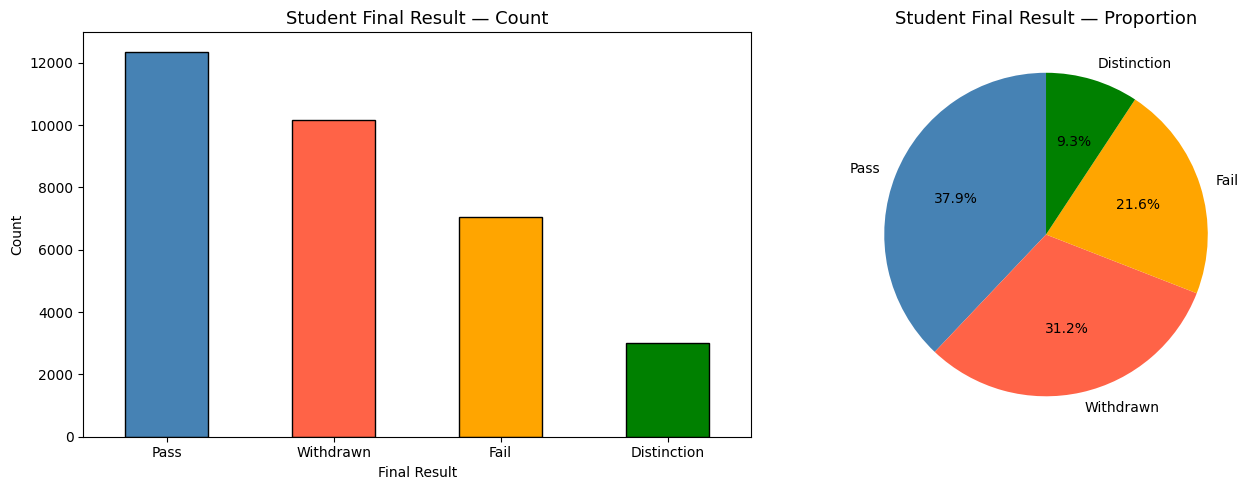

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = student_info['final_result'].value_counts()

# Bar chart
counts.plot(kind='bar', ax=axes[0],
            color=['steelblue', 'tomato', 'orange', 'green'],
            edgecolor='black')
axes[0].set_title('Student Final Result — Count', fontsize=13)
axes[0].set_xlabel('Final Result')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            startangle=90,
            colors=['steelblue', 'tomato', 'orange', 'green'])
axes[1].set_title('Student Final Result — Proportion', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('final_result_distribution.png', dpi=150)
plt.show()

## 4. Binary success indicator

A binary `passed` feature is created for simplified analysis. Pass and Distinction are coded as successful outcomes, while Fail and Withdrawn are coded as unsuccessful outcomes. The original `final_result` column is still kept for richer interpretation.

In [ ]:
# Create binary passed column
student_info['passed'] = student_info['final_result'].apply(
    lambda x: 1 if x in ['Pass', 'Distinction'] else 0
)

print('=== Binary Pass/Fail ===')
print(student_info['passed'].value_counts())
print(f'\nOverall pass rate: {student_info["passed"].mean()*100:.1f}%')

=== Binary Pass/Fail ===
passed
0    17208
1    15385
Name: count, dtype: int64

Overall pass rate: 47.2%


## 5. Missing value analysis in studentInfo

Missing values are checked before imputation or transformation. This is important because missingness can reflect data quality problems, disclosure choices, or structural absence.

In [ ]:
print('=== Missing Values in studentInfo ===\n')

missing = student_info.isnull().sum()
pct = (missing / len(student_info) * 100).round(2)
report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if report.empty:
    print('No missing values found!')
else:
    display(report)

=== Missing Values in studentInfo ===



,Missing Count,Missing %
imd_band,1111,3.41


### 5.1 IMD band missingness

`imd_band` is the socioeconomic deprivation variable. Missing values should not be silently removed because deletion can reduce coverage and affect fairness analysis.

In [ ]:
print('=== imd_band details ===\n')

total = len(student_info)
missing_count = student_info['imd_band'].isnull().sum()
print(f'Total students      : {total:,}')
print(f'Missing imd_band    : {missing_count:,}')
print(f'Missing percentage  : {missing_count/total*100:.2f}%')

print('\nExisting imd_band values:')
print(student_info['imd_band'].value_counts())

=== imd_band details ===

Total students      : 32,593
Missing imd_band    : 1,111
Missing percentage  : 3.41%

Existing imd_band values:
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Name: count, dtype: int64


### 5.2 Handling missing IMD values

Missing `imd_band` values are replaced with `Unknown`. This preserves the records and keeps non disclosure visible as its own category.

In [ ]:
# Fill missing imd_band with 'Unknown'
student_info['imd_band'].fillna('Unknown', inplace=True)

# Verify no more missing values
print('Missing values after fix:')
print(student_info['imd_band'].isnull().sum())

print('\nimd_band distribution now:')
print(student_info['imd_band'].value_counts())

Missing values after fix:
0

imd_band distribution now:
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Unknown    1111
Name: count, dtype: int64


C:\Users\pc\AppData\Local\Temp\ipykernel_18044\3992232676.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student_info['imd_band'].fillna('Unknown', inplace=True)


## 6. Missing value analysis in assessment submissions

`studentAssessment.csv` is checked separately because assessment records are central for performance features such as average score and number of submitted assessments.

In [ ]:
print('=== Missing Values in studentAssessment ===\n')
missing = student_assessment.isnull().sum()
pct = (missing / len(student_assessment) * 100).round(2)
report = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
report = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if report.empty:
    print('No missing values!')
else:
    display(report)

=== Missing Values in studentAssessment ===



,Missing Count,Missing %
score,173,0.1


### 6.1 Handling missing scores

Missing scores are filled with the median score. This is a simple classical preprocessing choice. For a more conservative modelling workflow, a missing score flag could also be added.

In [ ]:
# Check exact missing count first
missing_scores = student_assessment['score'].isnull().sum()
total = len(student_assessment)
print(f'Missing scores: {missing_scores:,} out of {total:,} ({missing_scores/total*100:.2f}%)')

# Fill with median
median_score = student_assessment['score'].median()
print(f'Median score: {median_score}')

student_assessment['score'].fillna(median_score, inplace=True)

# Verify
print(f'\nMissing after fix: {student_assessment["score"].isnull().sum()}')
print(' Done!')

Missing scores: 173 out of 173,912 (0.10%)
Median score: 80.0

Missing after fix: 0
 Done!


C:\Users\pc\AppData\Local\Temp\ipykernel_18044\1384362703.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  student_assessment['score'].fillna(median_score, inplace=True)


## 7. Outlier detection in assessment scores

The interquartile range method is used to identify unusual score values. The purpose is not to delete learners, but to understand whether extreme values exist and how frequent they are.

=== Score Distribution ===

Q1: 65.0 | Q3: 90.0 | IQR: 25.0
Lower bound: 27.5 | Upper bound: 127.5
Outliers found: 3,813 (2.19%)


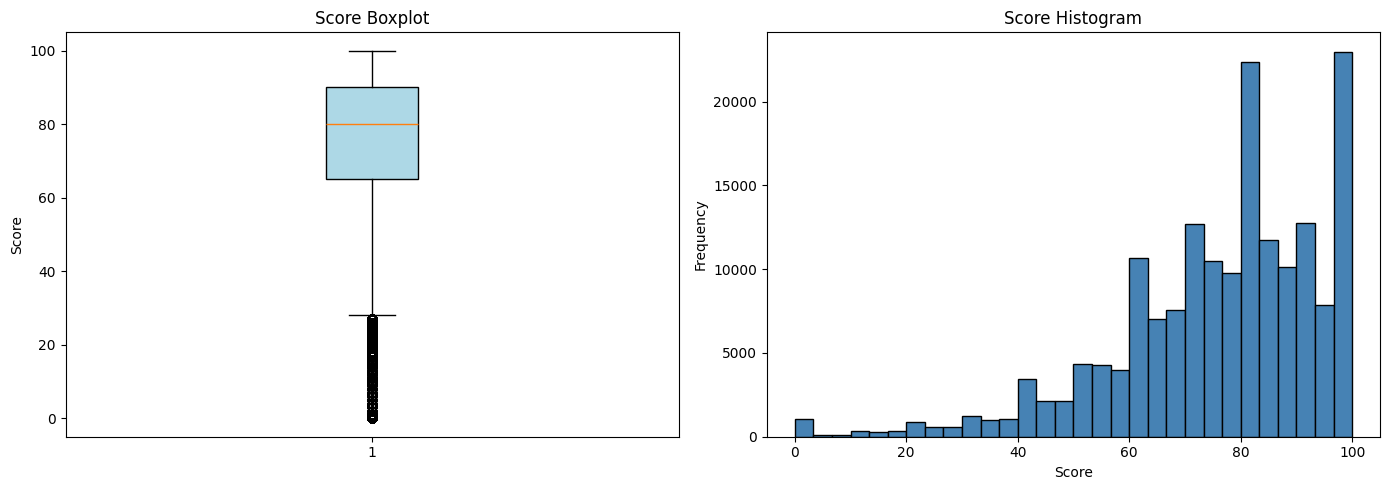

In [ ]:
print('=== Score Distribution ===\n')

Q1  = student_assessment['score'].quantile(0.25)
Q3  = student_assessment['score'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = student_assessment[
    (student_assessment['score'] < lower) |
    (student_assessment['score'] > upper)
]

print(f'Q1: {Q1} | Q3: {Q3} | IQR: {IQR}')
print(f'Lower bound: {lower} | Upper bound: {upper}')
print(f'Outliers found: {len(outliers):,} ({len(outliers)/len(student_assessment)*100:.2f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(student_assessment['score'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Score Boxplot')
axes[0].set_ylabel('Score')

axes[1].hist(student_assessment['score'].dropna(),
             bins=30, color='steelblue', edgecolor='black')
axes[1].set_title('Score Histogram')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 7.1 Outlier flagging decision

Score outliers are flagged instead of removed. This is appropriate because very low or unusual scores may represent real academic performance rather than data errors.

In [ ]:
# Flag outliers without removing them
student_assessment['is_outlier_score'] = (
    (student_assessment['score'] < lower) |
    (student_assessment['score'] > upper)
).astype(int)

print(f'Total outliers flagged: {student_assessment["is_outlier_score"].sum():,}')
print(f'Percentage: {student_assessment["is_outlier_score"].mean()*100:.2f}%')
print('\n Outliers flagged — no data removed!')

Total outliers flagged: 3,813
Percentage: 2.19%

 Outliers flagged — no data removed!


## 8. Outlier detection in VLE clicks

VLE click counts are highly skewed. The notebook uses the interquartile range method to identify very high interaction rows and then keeps the data while flagging the issue.

=== VLE Clicks Outlier Detection ===

Q1: 1.0 | Q3: 3.0 | IQR: 2.0
Lower bound: -2.0 | Upper bound: 6.0
Outliers found: 1,314,646 (12.34%)


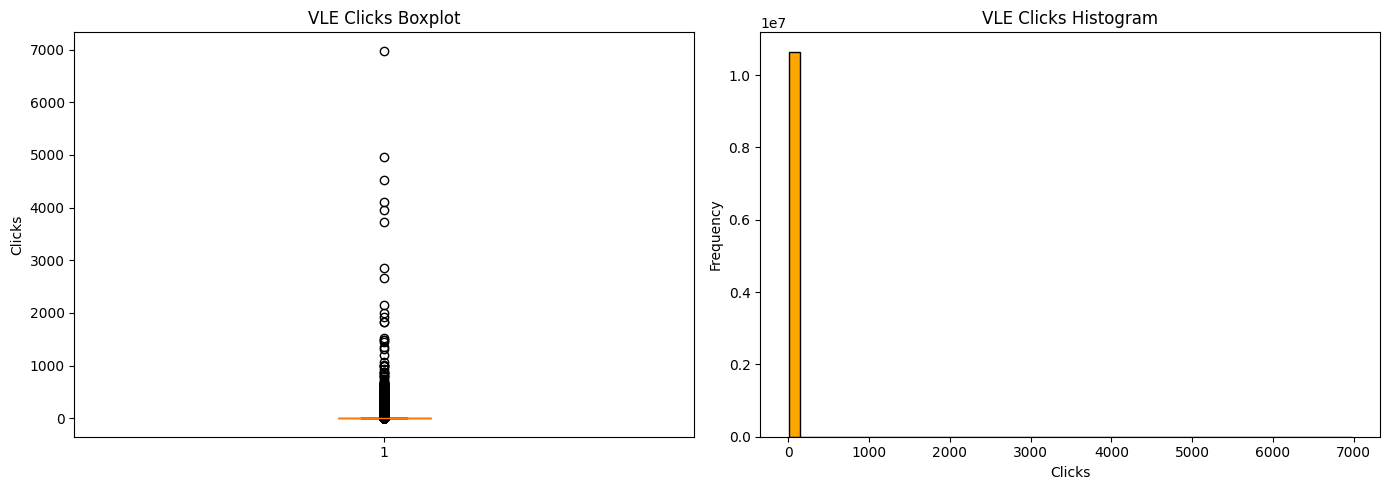


Outliers flagged: 1,314,646
 Done!


In [ ]:
print('=== VLE Clicks Outlier Detection ===\n')

Q1_c  = student_vle['sum_click'].quantile(0.25)
Q3_c  = student_vle['sum_click'].quantile(0.75)
IQR_c = Q3_c - Q1_c
lower_c = Q1_c - 1.5 * IQR_c
upper_c = Q3_c + 1.5 * IQR_c

outliers_clicks = student_vle[
    (student_vle['sum_click'] < lower_c) |
    (student_vle['sum_click'] > upper_c)
]

print(f'Q1: {Q1_c} | Q3: {Q3_c} | IQR: {IQR_c}')
print(f'Lower bound: {lower_c} | Upper bound: {upper_c}')
print(f'Outliers found: {len(outliers_clicks):,} ({len(outliers_clicks)/len(student_vle)*100:.2f}%)')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(student_vle['sum_click'], patch_artist=True,
                boxprops=dict(facecolor='lightyellow'))
axes[0].set_title('VLE Clicks Boxplot')
axes[0].set_ylabel('Clicks')

axes[1].hist(student_vle['sum_click'], bins=50,
             color='orange', edgecolor='black')
axes[1].set_title('VLE Clicks Histogram')
axes[1].set_xlabel('Clicks')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Flag outliers
student_vle['is_outlier_clicks'] = (
    (student_vle['sum_click'] < lower_c) |
    (student_vle['sum_click'] > upper_c)
).astype(int)

print(f'\nOutliers flagged: {student_vle["is_outlier_clicks"].sum():,}')
print(' Done!')

## 9. Feature engineering from VLE activity

The engineered behavioural features are now aggregated at the enrolment level instead of by `id_student` alone. The correct key is `code_module`, `code_presentation`, and `id_student`. This keeps each row linked to one module presentation and avoids mixing repeated students across different learning contexts.

In [ ]:
print('=== Feature Engineering at Enrolment Level ===\n')

# Correct unit of analysis for OULAD modelling
KEYS = ['code_module', 'code_presentation', 'id_student']

print(f'Enrolment records in studentInfo: {len(student_info):,}')
print(f'Unique students in studentInfo  : {student_info["id_student"].nunique():,}')
print(f'Unique enrolment keys           : {student_info[KEYS].drop_duplicates().shape[0]:,}')

# Feature 1: Total VLE clicks per enrolment
vle_clicks = (
    student_vle
    .groupby(KEYS)
    .agg(
        total_clicks=('sum_click', 'sum'),
        avg_clicks_per_day=('sum_click', 'mean'),
        active_days=('date', 'nunique')
    )
)

print(f'Feature 1 — VLE features created: {len(vle_clicks):,} enrolments')
display(vle_clicks.head())

=== Feature Engineering at Enrolment Level ===

Enrolment records in studentInfo: 32,593
Unique students in studentInfo  : 28,785
Unique enrolment keys           : 32,593


C:\Users\pc\AppData\Local\Temp\ipykernel_18044\3147792417.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(KEYS)


Feature 1 — VLE features created: 730,072 enrolments


total_clicks  avg_clicks_per_day  \
code_module code_presentation id_student                                     
AAA         2013J             6516                   0                 NaN   
                              8462                   0                 NaN   
                              11391                934            4.765306   
                              23629                  0                 NaN   
                              23698                  0                 NaN   

                                          active_days  
code_module code_presentation id_student               
AAA         2013J             6516                  0  
                              8462                  0  
                              11391                40  
                              23629                 0  
                              23698                 0

### 9.1 Core engineered features

The main engineered features are total clicks, average assessment score, number of submitted assessments, active days, and the binary pass indicator. The assessment and VLE features use the same enrolment-level key so that each row remains aligned with one `final_result` value.

In [ ]:
# Add module and presentation information to assessment submissions
assessment_joined = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment',
    how='left'
)

# Feature 2 and 3: Assessment features per enrolment
assessment_features = (
    assessment_joined
    .groupby(KEYS, as_index=False)
    .agg(
        avg_score=('score', 'mean'),
        num_assessments_submitted=('id_assessment', 'count')
    )
)

print(f'Feature 2 — avg_score created: {len(assessment_features):,} enrolments')
print(f'Feature 3 — num_assessments_submitted created: {len(assessment_features):,} enrolments')
print('Feature 4 — passed column already exists in student_info')

print('\n--- Assessment features sample ---')
display(assessment_features.head())
print('\n--- VLE features sample ---')
display(vle_clicks.head())

Feature 2 — avg_score created: 25,843 enrolments
Feature 3 — num_assessments_submitted created: 25,843 enrolments
Feature 4 — passed column already exists in student_info

--- Assessment features sample ---


,code_module,code_presentation,id_student,avg_score,num_assessments_submitted
0,AAA,2013J,11391,82.0,5
1,AAA,2013J,28400,66.4,5
2,AAA,2013J,31604,76.0,5
3,AAA,2013J,32885,54.4,5
4,AAA,2013J,38053,68.0,5



--- VLE features sample ---


total_clicks  avg_clicks_per_day  \
code_module code_presentation id_student                                     
AAA         2013J             6516                   0                 NaN   
                              8462                   0                 NaN   
                              11391                934            4.765306   
                              23629                  0                 NaN   
                              23698                  0                 NaN   

                                          active_days  
code_module code_presentation id_student               
AAA         2013J             6516                  0  
                              8462                  0  
                              11391                40  
                              23629                 0  
                              23698                 0

## 10. Building the master dataframe

The master dataframe starts from `studentInfo.csv` and merges engineered assessment and VLE features using the enrolment-level key: `code_module`, `code_presentation`, and `id_student`. Enrolments without VLE activity or assessment records are retained by filling missing engineered values with zero where appropriate.

In [ ]:
print('=== Building Master DataFrame ===\n')

# Start with studentInfo as the base enrolment table
master_df = student_info.copy()

# Merge assessment features using the correct enrolment-level key
master_df = master_df.merge(assessment_features, on=KEYS, how='left')
print(f'After merging assessment features: {master_df.shape}')

# Merge VLE features using the same key
master_df = master_df.merge(vle_clicks, on=KEYS, how='left')
print(f'After merging VLE features       : {master_df.shape}')

# Fill NaN for enrolments with no VLE or assessment data
fill_zero_cols = [
    'avg_score',
    'num_assessments_submitted',
    'total_clicks',
    'avg_clicks_per_day',
    'active_days'
]

for col in fill_zero_cols:
    master_df[col] = master_df[col].fillna(0)

print('\nMaster DataFrame ready!')
print(f'Final shape: {master_df.shape}')
print(f'Unique students: {master_df["id_student"].nunique():,}')
print(f'Unique enrolment records: {master_df[KEYS].drop_duplicates().shape[0]:,}')
print(f'\nColumns: {list(master_df.columns)}')
display(master_df.head())

=== Building Master DataFrame ===

After merging assessment features: (32593, 15)
After merging VLE features       : (32593, 18)

Master DataFrame ready!
Final shape: (32593, 18)
Unique students: 28,785
Unique enrolment records: 32,593

Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'passed', 'avg_score', 'num_assessments_submitted', 'total_clicks', 'avg_clicks_per_day', 'active_days']


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,passed,avg_score,num_assessments_submitted,total_clicks,avg_clicks_per_day,active_days
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1,82.0,5.0,934.0,4.765306,40.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1,66.4,5.0,1435.0,3.337209,80.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,0,0.0,0.0,281.0,3.697368,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1,76.0,5.0,2158.0,3.254902,123.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1,54.4,5.0,1034.0,2.937500,70.0


## 11. Categorical variable inspection

Categorical columns are reviewed before encoding. This helps identify which variables are binary and which require one hot encoding.

In [ ]:
print('=== Categorical Columns ===\n')

cat_cols = master_df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    unique_vals = master_df[col].nunique()
    print(f'{col:25s} → {unique_vals} unique values: {master_df[col].unique()[:5]}')

=== Categorical Columns ===

code_module               → 7 unique values: ['AAA' 'BBB' 'CCC' 'DDD' 'EEE']
code_presentation         → 4 unique values: ['2013J' '2014J' '2013B' '2014B']
gender                    → 2 unique values: ['M' 'F']
region                    → 13 unique values: ['East Anglian Region' 'Scotland' 'North Western Region'
 'South East Region' 'West Midlands Region']
highest_education         → 5 unique values: ['HE Qualification' 'A Level or Equivalent' 'Lower Than A Level'
 'Post Graduate Qualification' 'No Formal quals']
imd_band                  → 11 unique values: ['90-100%' '20-30%' '30-40%' '50-60%' '80-90%']
age_band                  → 3 unique values: ['55<=' '35-55' '0-35']
disability                → 2 unique values: ['N' 'Y']
final_result              → 4 unique values: ['Pass' 'Withdrawn' 'Fail' 'Distinction']


## 12. Encoding categorical variables

Binary variables such as gender and disability are label encoded. Multi category variables such as age band, education, region, and IMD band are one hot encoded so they can be used in machine learning models.

In [ ]:
from sklearn.preprocessing import LabelEncoder

print('=== Categorical Encoding ===\n')

# Label Encoding for binary columns
le = LabelEncoder()

master_df['gender_encoded']     = le.fit_transform(master_df['gender'])
master_df['disability_encoded'] = le.fit_transform(master_df['disability'])

print('Label Encoding done:')
print(f'   gender     : {dict(zip(le.classes_, le.transform(le.classes_)))}')

le2 = LabelEncoder()
master_df['disability_encoded'] = le2.fit_transform(master_df['disability'])
print(f'   disability : {dict(zip(le2.classes_, le2.transform(le2.classes_)))}')

# One-Hot Encoding for multi-class columns
master_df = pd.get_dummies(master_df,
                           columns=['age_band',
                                    'highest_education',
                                    'region',
                                    'imd_band'],
                           drop_first=False)

print(f'\n One-Hot Encoding done!')
print(f'Shape after encoding: {master_df.shape}')
print(f'\nNew columns added: {[c for c in master_df.columns if "_" in c][-10:]}')

=== Categorical Encoding ===

Label Encoding done:
   gender     : {'N': np.int64(0), 'Y': np.int64(1)}
   disability : {'N': np.int64(0), 'Y': np.int64(1)}

 One-Hot Encoding done!
Shape after encoding: (32593, 48)

New columns added: ['imd_band_10-20', 'imd_band_20-30%', 'imd_band_30-40%', 'imd_band_40-50%', 'imd_band_50-60%', 'imd_band_60-70%', 'imd_band_70-80%', 'imd_band_80-90%', 'imd_band_90-100%', 'imd_band_Unknown']


## 13. Visual analysis of demographic patterns

The notebook visualizes pass rates by gender and disability to check whether important group level differences appear after preprocessing.

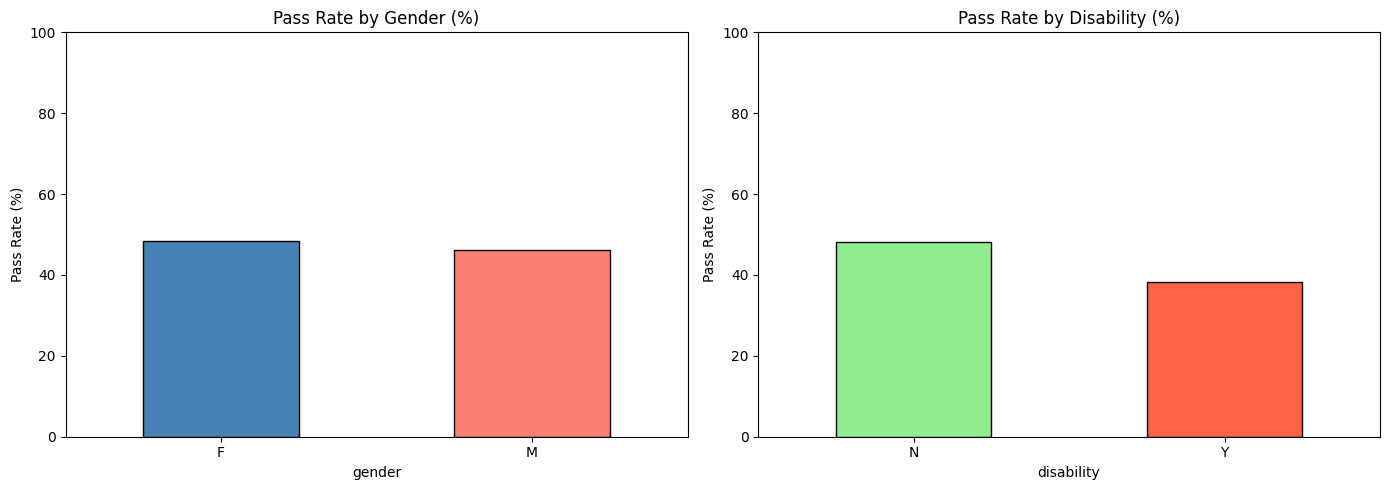

In [ ]:
# Chart 1: Pass rate by gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_pass = master_df.groupby('gender')['passed'].mean() * 100
gender_pass.plot(kind='bar', ax=axes[0],
                 color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Pass Rate by Gender (%)')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=0)

# Chart 2: Pass rate by disability
dis_pass = master_df.groupby('disability')['passed'].mean() * 100
dis_pass.plot(kind='bar', ax=axes[1],
              color=['lightgreen', 'tomato'], edgecolor='black')
axes[1].set_title('Pass Rate by Disability (%)')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('pass_rates_demographics.png', dpi=150)
plt.show()

## 14. Visual analysis of engagement and outcome

A boxplot compares total VLE clicks across final result categories. This supports the project finding that engagement is related to outcomes, while still needing careful interpretation.

C:\Users\pc\AppData\Local\Temp\ipykernel_18044\441455211.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='final_result', y='total_clicks', data=master_df,


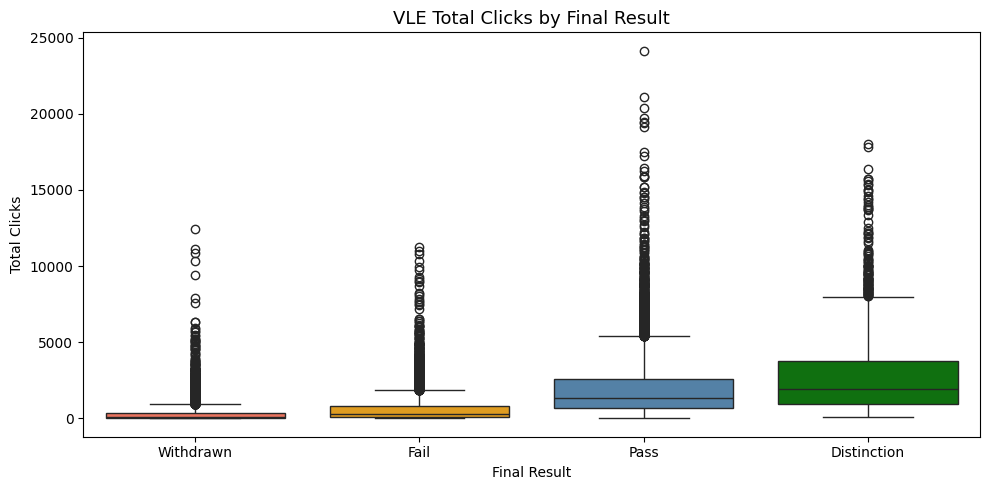

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chart 3: VLE clicks vs final result
plt.figure(figsize=(10, 5))
sns.boxplot(x='final_result', y='total_clicks', data=master_df,
            order=['Withdrawn', 'Fail', 'Pass', 'Distinction'],
            palette=['tomato', 'orange', 'steelblue', 'green'])
plt.title('VLE Total Clicks by Final Result', fontsize=13)
plt.xlabel('Final Result')
plt.ylabel('Total Clicks')
plt.tight_layout()
plt.savefig('vle_clicks_by_result.png', dpi=150)
plt.show()

## 15. Correlation analysis

The heatmap summarizes linear relationships among key numeric variables such as average score, total clicks, assessment submissions, studied credits, previous attempts, and the binary pass outcome.

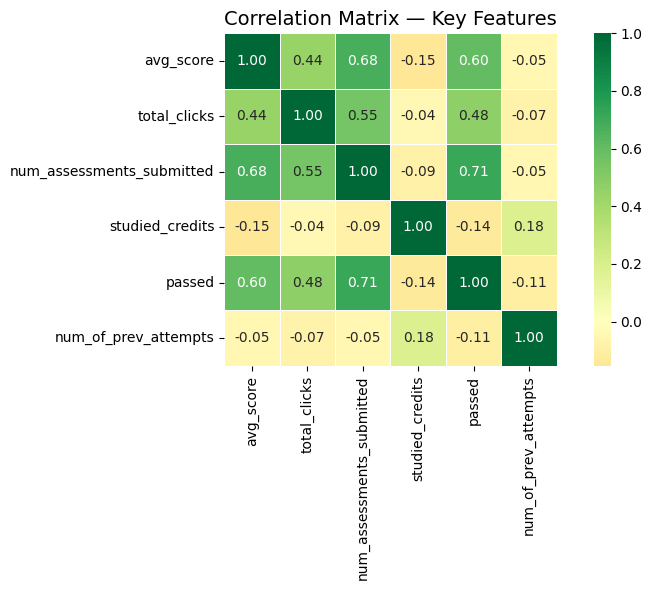

In [ ]:
# Chart 4: Correlation heatmap
numeric_cols = ['avg_score', 'total_clicks',
                'num_assessments_submitted',
                'studied_credits', 'passed',
                'num_of_prev_attempts']

corr = master_df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix — Key Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

## 16. Exporting the cleaned dataset

The final step saves the cleaned master dataframe as `master_cleaned.csv`. This exported table is the main output of the classical preprocessing workflow.

In [ ]:
# Save master DataFrame
master_df.to_csv('master_cleaned.csv', index=False)

print('Cleaned dataset saved!')
print(f'Final shape : {master_df.shape}')
print(f'Total enrolment records : {len(master_df):,}')
print(f'Unique students         : {master_df["id_student"].nunique():,}')
print(f'Unique enrolment keys   : {master_df[KEYS].drop_duplicates().shape[0]:,}')
print(f'\n=== PHASE 1 COMPLETE ===')
print(f'\nKey findings:')
print(f'  - Pass rate                    : {master_df["passed"].mean()*100:.1f}%')
print(f'  - Avg score                    : {master_df["avg_score"].mean():.1f}')
print(f'  - Avg total clicks             : {master_df["total_clicks"].mean():.0f}')
print(f'  - Features now use enrolment-level keys')
print(f'  - Gender gap                   : check demographic pass-rate chart')
print(f'  - Disability gap               : check demographic pass-rate chart')
print(f'  - Distinction students         : compare VLE engagement by final result')

Cleaned dataset saved!
Final shape : (32593, 48)
Total enrolment records : 32,593
Unique students         : 28,785
Unique enrolment keys   : 32,593

=== PHASE 1 COMPLETE ===

Key findings:
  - Pass rate                    : 47.2%
  - Avg score                    : 57.7
  - Avg total clicks             : 1215
  - Features now use enrolment-level keys
  - Gender gap                   : check demographic pass-rate chart
  - Disability gap               : check demographic pass-rate chart
  - Distinction students         : compare VLE engagement by final result


Ps:
Engineered VLE and assessment variables are aggregated by the enrolment-level key: `code_module`, `code_presentation`, and `id_student`.
This matters because OULAD contains 32,593 enrolment records and 28,785 unique students. A learner can appear in more than one module presentation, so using only `id_student` can mix different learning contexts. 